# EDA - Gym Churn Predictor

Este notebook documenta a analise exploratoria da base `gym_churn_us.csv` para a entrega da Semana 5 do projeto de predicao de churn.

Objetivos:

- carregar a base de clientes;
- verificar qualidade dos dados;
- limpar duplicados e nulos;
- visualizar a distribuicao de churn;
- comparar clientes que ficaram versus clientes que cancelaram;
- justificar as features usadas no modelo preditivo.

## 1. Importacao de bibliotecas e configuracao

O notebook usa `pandas` para manipulacao dos dados e `matplotlib` para graficos simples. A base deve estar em `dataset/gym_churn_us.csv` na raiz do projeto.

In [1]:
import importlib.util
import subprocess
import sys

required_packages = {
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "scikit-learn": "sklearn",
}

missing_packages = [
    package
    for package, module in required_packages.items()
    if importlib.util.find_spec(module) is None
]

if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])

print(f"Kernel Python: {sys.executable}")
print("Dependencias prontas para a EDA.")

Kernel Python: /Users/allexfernandescatarina/anaconda3/bin/python
Dependencias prontas para a EDA.


In [2]:
import numpy as np

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter

FEATURES = [
    "Lifetime",
    "Avg_class_frequency_current_month",
    "Age",
    "Contract_period",
    "Month_to_end_contract",
    "Avg_class_frequency_total",
    "Avg_additional_charges_total",
    "Group_visits",
    "Promo_friends",
    "Partner",
    "Near_Location",
]

# Tokens visuais espelhados no frontend do projeto.
COLOR_BRAND = "#00c4a7"
COLOR_BRAND_STRONG = "#009f8a"
COLOR_HIGH = "#ff4d6d"
COLOR_TEXT = "#111827"
COLOR_MUTED = "#64748b"
COLOR_BORDER = "#e5e7eb"
COLOR_SURFACE = "#ffffff"
COLOR_SURFACE_MUTED = "#f8fafc"
COLOR_WARNING = "#b45309"

CHURN_COLORS = {0: COLOR_BRAND, 1: COLOR_HIGH}
CORRELATION_CMAP = LinearSegmentedColormap.from_list(
    "gym_churn_correlation",
    [COLOR_BRAND, COLOR_SURFACE, COLOR_HIGH],
)

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": COLOR_SURFACE,
    "axes.facecolor": COLOR_SURFACE,
    "axes.edgecolor": COLOR_BORDER,
    "axes.labelcolor": COLOR_MUTED,
    "axes.titlecolor": COLOR_TEXT,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.color": COLOR_BORDER,
    "grid.alpha": 0.55,
    "grid.linewidth": 0.8,
    "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED,
    "font.family": "DejaVu Sans",
    "font.size": 10,
})
pd.set_option("display.max_columns", 50)


def criar_boxplot_status(ax, box_data):
    boxplot_kwargs = dict(
        patch_artist=True,
        medianprops={"color": COLOR_TEXT, "linewidth": 1.4},
        whiskerprops={"color": COLOR_MUTED},
        capprops={"color": COLOR_MUTED},
        flierprops={"markerfacecolor": COLOR_BORDER, "markeredgecolor": COLOR_BORDER, "alpha": 0.35},
    )
    try:
        bp = ax.boxplot(box_data, tick_labels=["Ficou", "Cancelou"], **boxplot_kwargs)
    except TypeError:
        bp = ax.boxplot(box_data, labels=["Ficou", "Cancelou"], **boxplot_kwargs)
    for patch, color in zip(bp["boxes"], [COLOR_BRAND, COLOR_HIGH]):
        patch.set_facecolor(color)
        patch.set_alpha(0.18)
        patch.set_edgecolor(color)
    return bp

def aplicar_estilo_axis(ax, title=None, xlabel=None, ylabel=None, grid_axis="y"):
    if title:
        ax.set_title(title, pad=12, fontweight="bold", color=COLOR_TEXT)
    if xlabel is not None:
        ax.set_xlabel(xlabel, color=COLOR_MUTED, fontweight="bold")
    if ylabel is not None:
        ax.set_ylabel(ylabel, color=COLOR_MUTED, fontweight="bold")
    ax.grid(True, axis=grid_axis, color=COLOR_BORDER, alpha=0.55)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(COLOR_BORDER)
    ax.spines["bottom"].set_color(COLOR_BORDER)
    return ax

candidate_paths = [
    Path("notebooks/gym_churn_us.csv"),
    Path("dataset/gym_churn_us.csv"),
    Path("../dataset/gym_churn_us.csv"),
    Path("gym_churn_us.csv"),
    Path.home() / "Downloads" / "gym_churn_us.csv",
]

DATA_PATH = next((path for path in candidate_paths if path.exists()), None)

if DATA_PATH is None:
    paths_text = "\n".join(f"- {path.resolve()}" for path in candidate_paths)
    raise FileNotFoundError(
        "CSV gym_churn_us.csv nao encontrado. Coloque o arquivo em uma destas pastas e rode novamente:\n"
        f"{paths_text}"
    )

print(f"CSV encontrado em: {DATA_PATH.resolve()}")
DATA_PATH

CSV encontrado em: /Users/allexfernandescatarina/Modulo2-G6/Modulo2-G6/notebooks/gym_churn_us.csv


## 2. Carga da base

A primeira etapa da EDA e carregar o arquivo CSV e conferir dimensoes, colunas e primeiras linhas.

In [4]:
df = pd.read_csv(DATA_PATH)

print(f"Linhas: {df.shape[0]:,}".replace(",", "."))
print(f"Colunas: {df.shape[1]}")
df.head()

Linhas: 4.000
Colunas: 14


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

## 3. Qualidade dos dados

Aqui verificamos valores nulos, duplicados e a distribuicao da variavel alvo `Churn`.

In [6]:
quality_summary = pd.DataFrame({
    "nulos": df.isna().sum(),
    "tipo": df.dtypes.astype(str),
    "valores_unicos": df.nunique(),
})

print(f"Duplicados: {df.duplicated().sum()}")
quality_summary

Duplicados: 0


In [7]:
df_clean = df.drop_duplicates().dropna().copy()

print(f"Shape original: {df.shape}")
print(f"Shape apos limpeza: {df_clean.shape}")
print(f"Linhas removidas: {len(df) - len(df_clean)}")

Shape original: (4000, 14)
Shape apos limpeza: (4000, 14)
Linhas removidas: 0


## 4. Distribuicao do churn

A variavel `Churn` indica se o cliente cancelou (`1`) ou permaneceu (`0`).

Churn
0    2939
1    1061
Name: count, dtype: int64
Taxa de churn: 26.52%


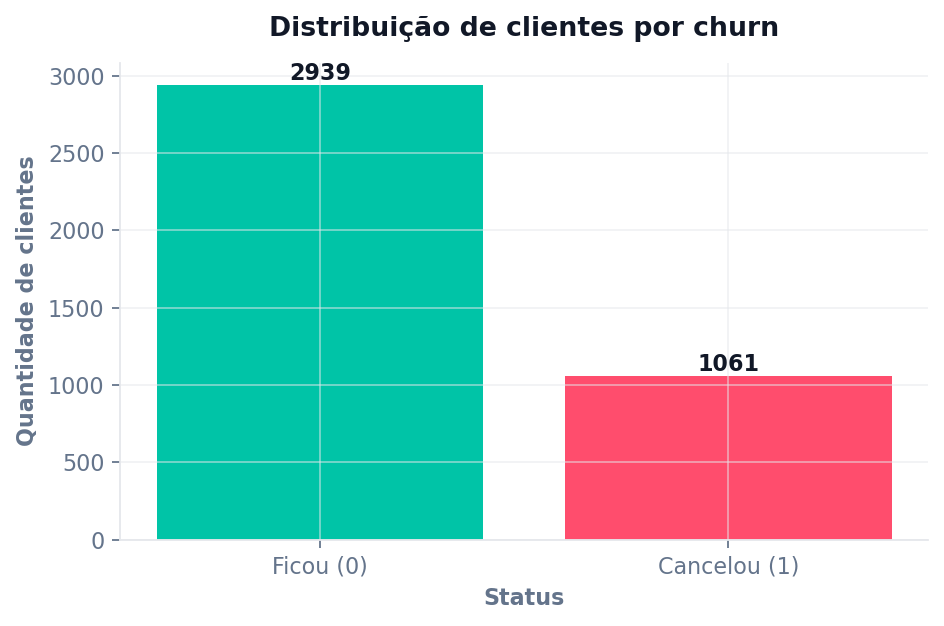

In [8]:
churn_counts = df_clean["Churn"].value_counts().sort_index()
churn_rate = df_clean["Churn"].mean()

print(churn_counts)
print(f"Taxa de churn: {churn_rate:.2%}")

fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Ficou (0)", "Cancelou (1)"]
bars = ax.bar(labels, churn_counts.values, color=[COLOR_BRAND, COLOR_HIGH], edgecolor="none")
aplicar_estilo_axis(ax, "Distribuição de clientes por churn", "Status", "Quantidade de clientes")
ax.bar_label(bars, color=COLOR_TEXT, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Estatisticas descritivas

As estatisticas ajudam a entender escala, dispersao e comportamento das variaveis numericas.

In [9]:
df_clean.describe().T

## 6. Comparacao entre clientes que ficaram e cancelaram

A comparacao por grupos mostra quais variaveis mudam mais entre clientes com `Churn = 0` e `Churn = 1`.

In [10]:
features_comparacao = [
    "Lifetime",
    "Avg_class_frequency_current_month",
    "Age",
    "Contract_period",
    "Month_to_end_contract",
    "Avg_class_frequency_total",
    "Avg_additional_charges_total",
]

group_means = df_clean.groupby("Churn")[features_comparacao].mean().T
group_means.columns = ["Ficou (0)", "Cancelou (1)"]
group_means.round(2)

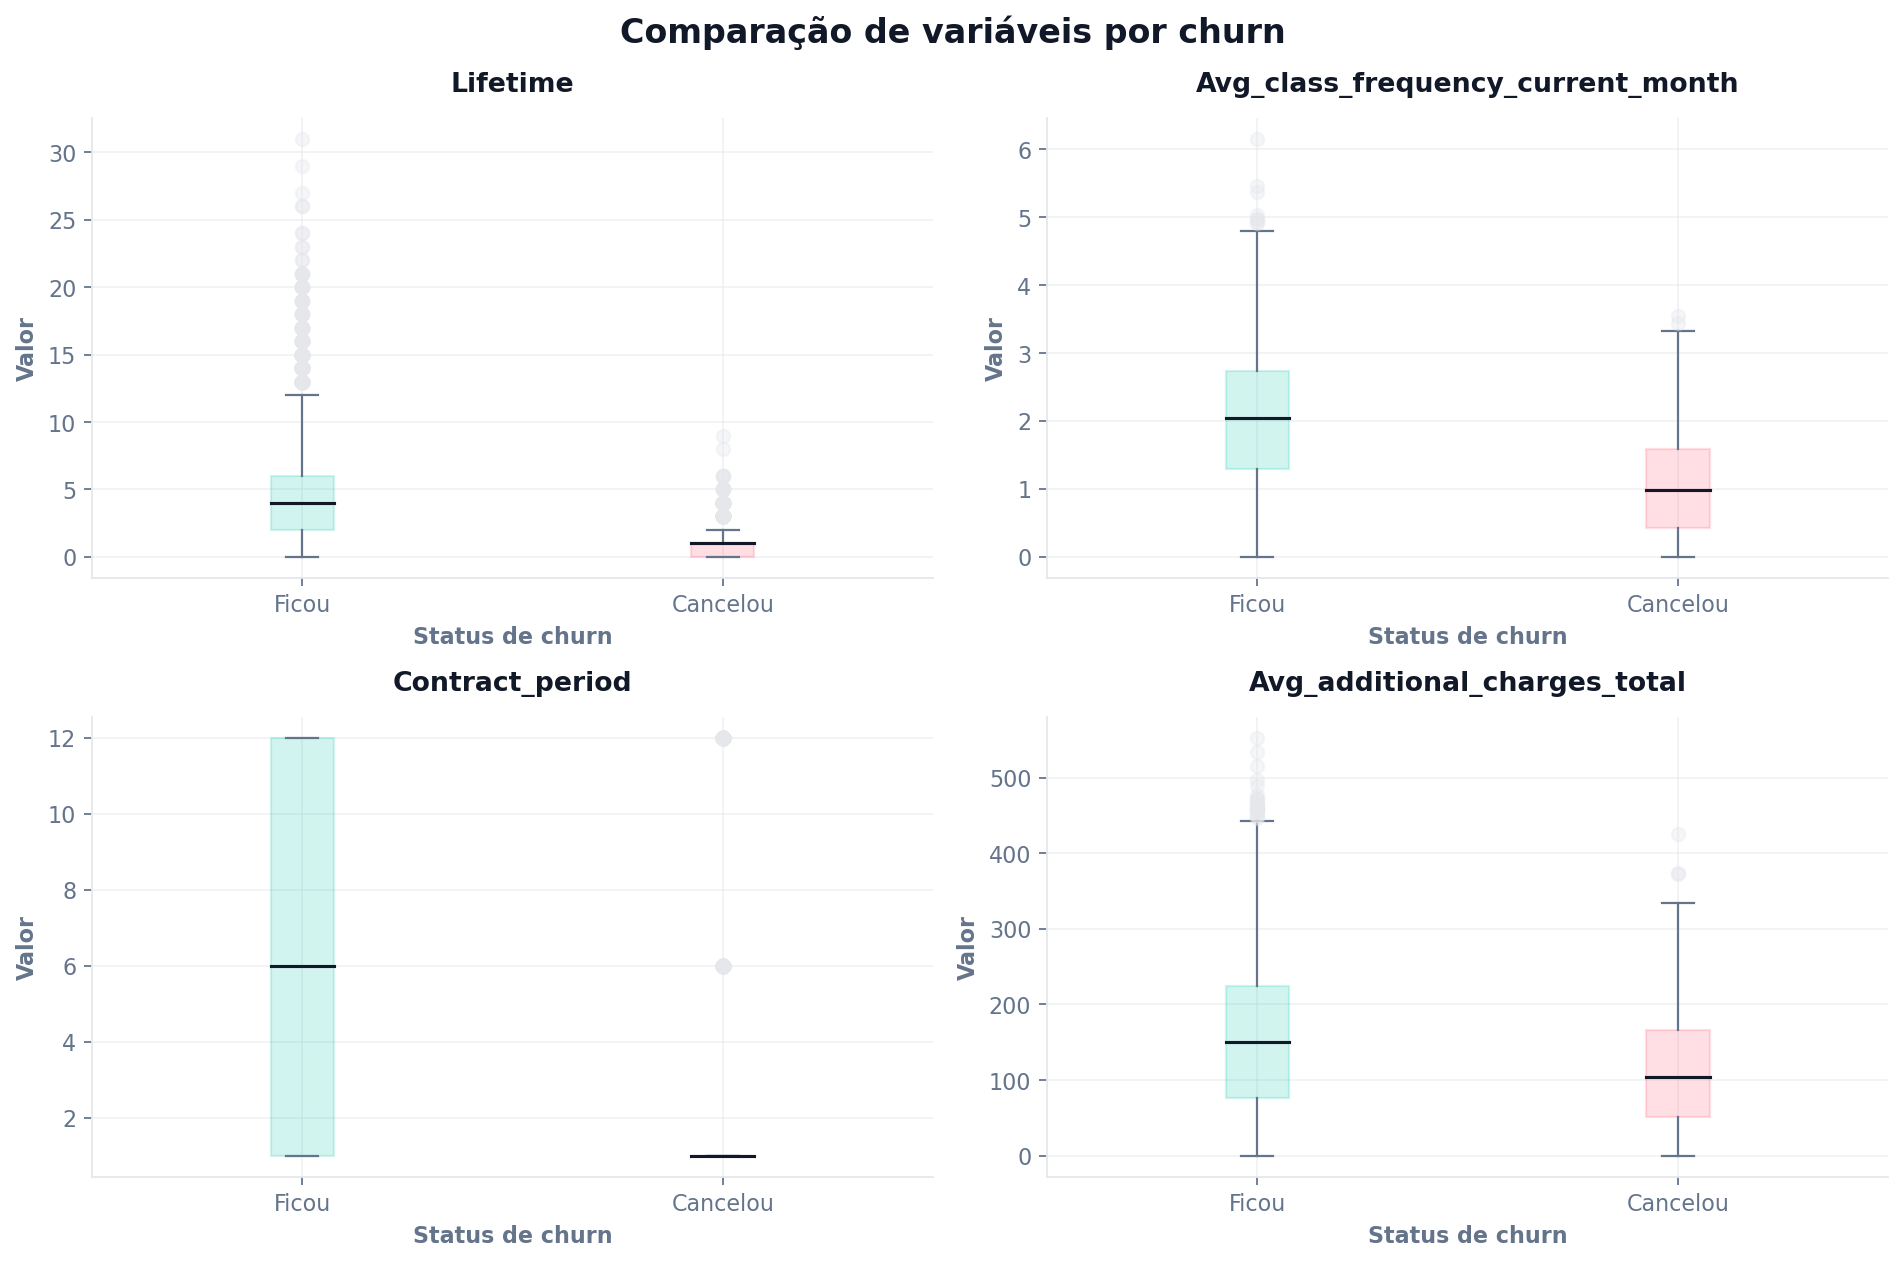

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

plot_features = [
    "Lifetime",
    "Avg_class_frequency_current_month",
    "Contract_period",
    "Avg_additional_charges_total",
]

for ax, feature in zip(axes, plot_features):
    box_data = [
        df_clean.loc[df_clean["Churn"] == 0, feature],
        df_clean.loc[df_clean["Churn"] == 1, feature],
    ]
    criar_boxplot_status(ax, box_data)
    aplicar_estilo_axis(ax, feature, "Status de churn", "Valor")

fig.suptitle("Comparação de variáveis por churn", fontsize=15, fontweight="bold", color=COLOR_TEXT)
plt.tight_layout()
plt.show()

## 7. Variaveis categoricas/binarias

As variaveis binarias ajudam a observar diferencas de comportamento em grupos como aulas em grupo, indicacao e proximidade da academia.

In [12]:
binary_features = ["Group_visits", "Promo_friends", "Partner", "Near_Location"]

binary_churn = []
for feature in binary_features:
    rates = df_clean.groupby(feature)["Churn"].mean().rename("churn_rate")
    for value, rate in rates.items():
        binary_churn.append({"feature": feature, "valor": value, "churn_rate": rate})

pd.DataFrame(binary_churn).round(3)

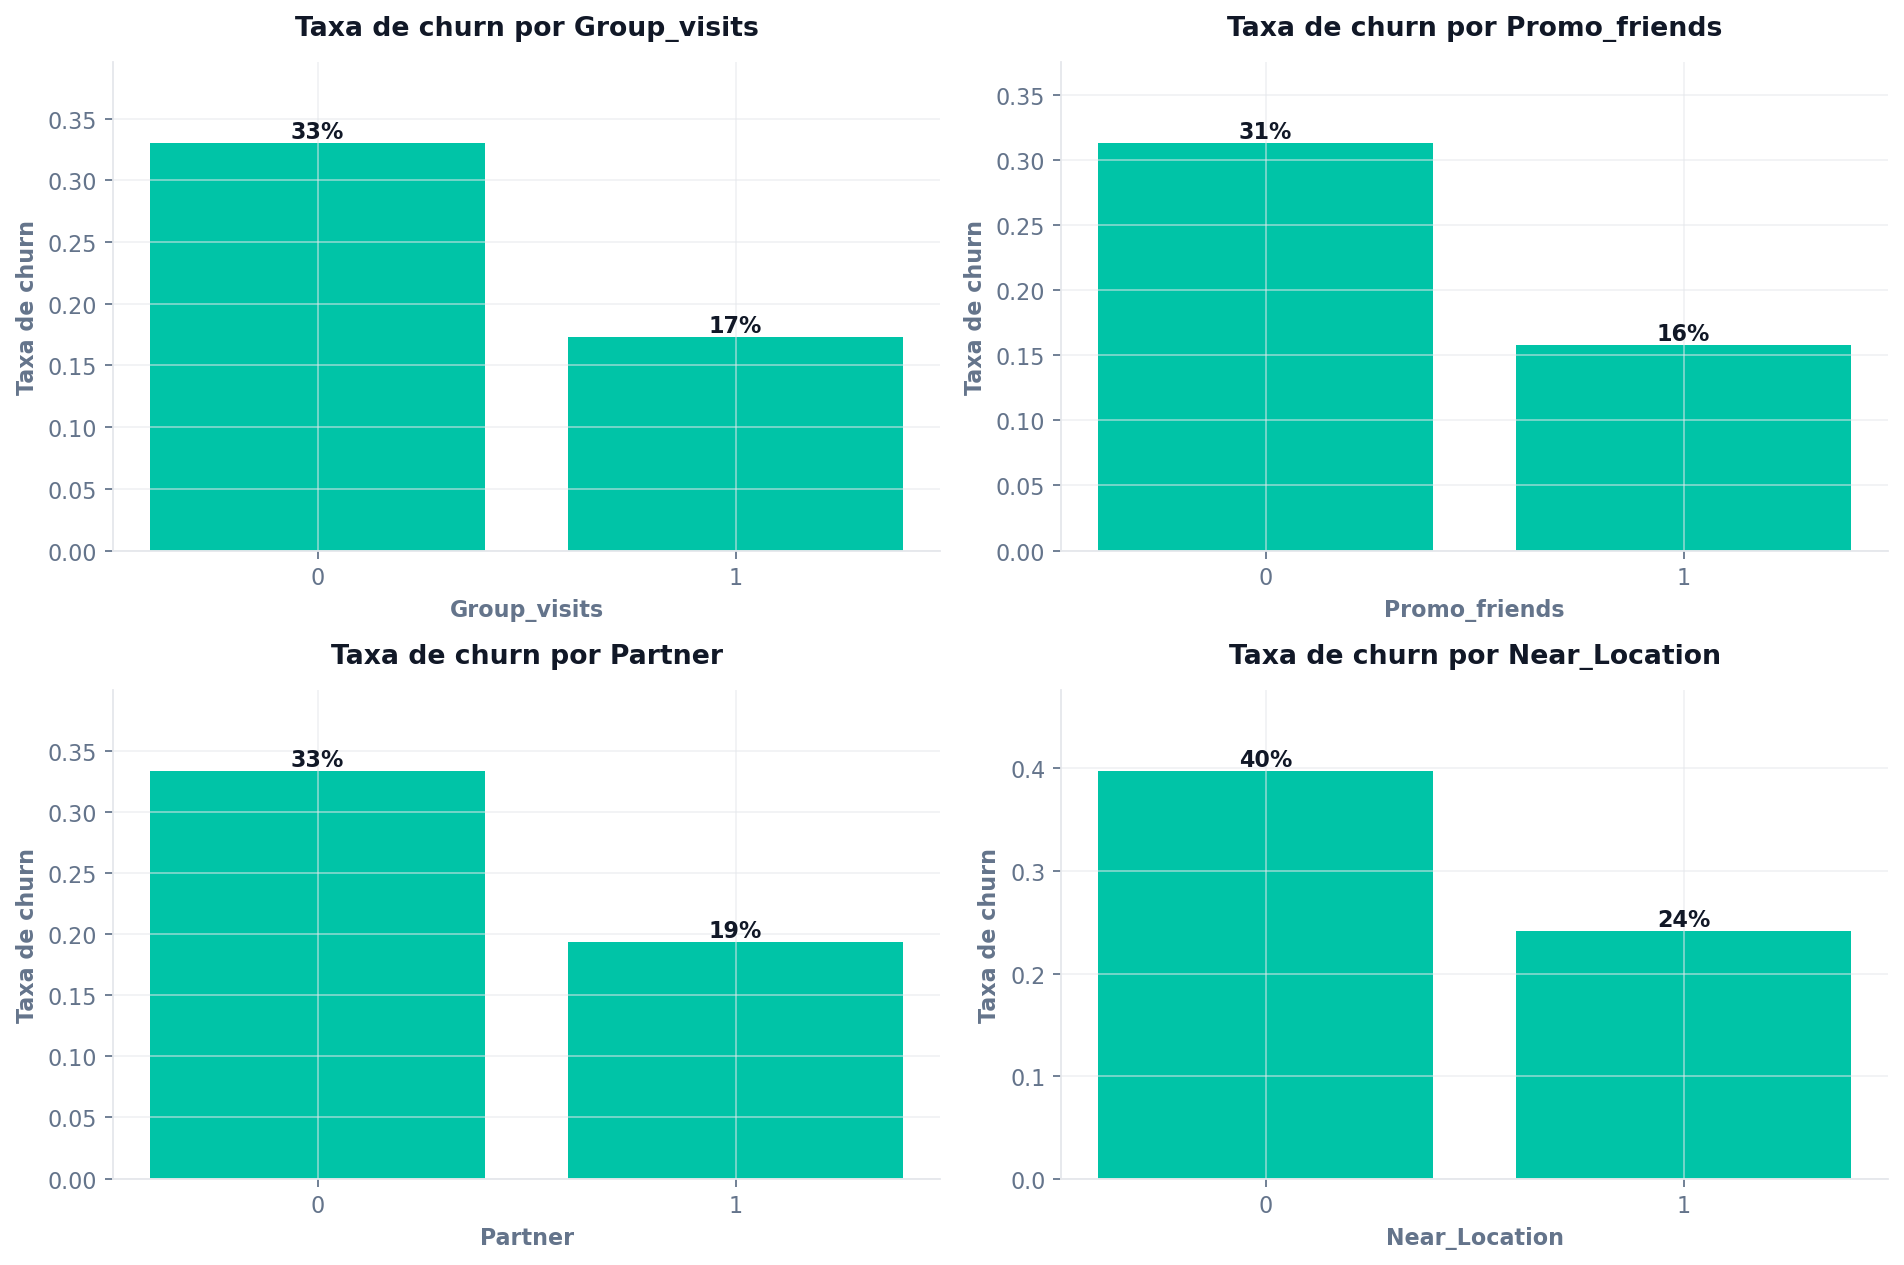

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, feature in zip(axes, binary_features):
    rates = df_clean.groupby(feature)["Churn"].mean().sort_index()
    bars = ax.bar(rates.index.astype(str), rates.values, color=COLOR_BRAND, edgecolor="none")
    aplicar_estilo_axis(ax, f"Taxa de churn por {feature}", feature, "Taxa de churn")
    ax.set_ylim(0, max(rates.max() * 1.2, 0.1))
    ax.bar_label(bars, labels=[f"{value:.0%}" for value in rates.values], color=COLOR_TEXT, fontweight="bold")

plt.tight_layout()
plt.show()

## 8. Correlacao com churn e selecao de features

A correlacao e usada aqui como uma analise inicial para orientar a selecao de features. Variaveis com correlacao proxima de zero tendem a contribuir pouco nesta primeira versao.

In [14]:
corr = df_clean.corr(numeric_only=True)["Churn"].sort_values(key=lambda s: s.abs(), ascending=False)
corr_df = corr.drop("Churn").to_frame("correlacao_com_churn")
corr_df

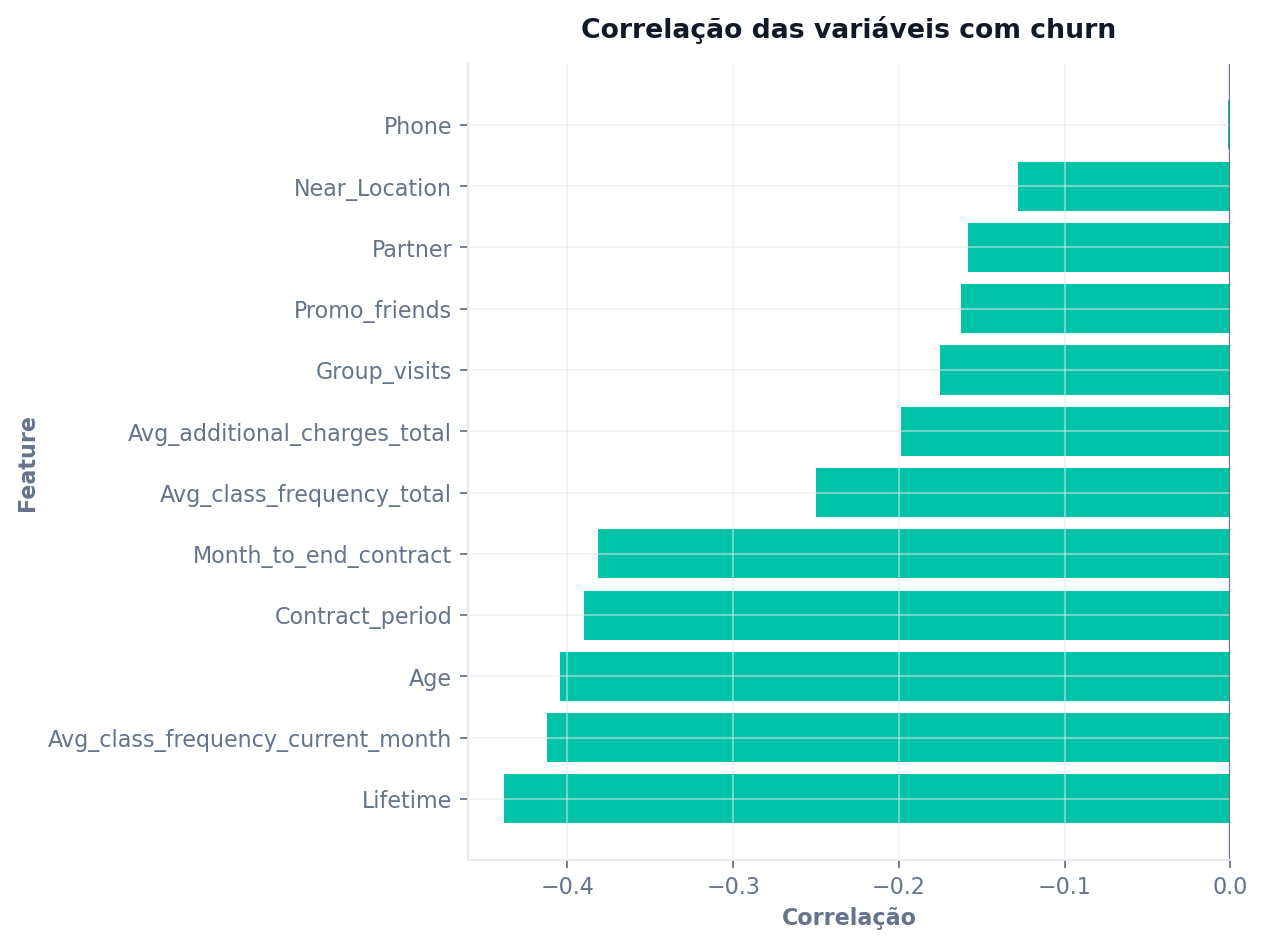

In [15]:
top_corr = corr_df.head(12).sort_values("correlacao_com_churn")

fig, ax = plt.subplots(figsize=(8, 6))
colors = [COLOR_HIGH if value > 0 else COLOR_BRAND for value in top_corr["correlacao_com_churn"]]
ax.barh(top_corr.index, top_corr["correlacao_com_churn"], color=colors, edgecolor="none")
aplicar_estilo_axis(ax, "Correlação das variáveis com churn", "Correlação", "Feature", grid_axis="x")
ax.axvline(0, color=COLOR_MUTED, linewidth=1)
plt.tight_layout()
plt.show()

In [16]:
features_modelo = [
    "Lifetime",
    "Avg_class_frequency_current_month",
    "Age",
    "Contract_period",
    "Month_to_end_contract",
    "Avg_class_frequency_total",
    "Avg_additional_charges_total",
    "Group_visits",
    "Promo_friends",
    "Partner",
    "Near_Location",
]

descartadas = [col for col in ["gender", "Phone"] if col in df_clean.columns]

print("Features usadas no modelo:")
print(features_modelo)
print("\nFeatures descartadas por baixa relacao inicial com churn:")
print(descartadas)

Features usadas no modelo:
['Lifetime', 'Avg_class_frequency_current_month', 'Age', 'Contract_period', 'Month_to_end_contract', 'Avg_class_frequency_total', 'Avg_additional_charges_total', 'Group_visits', 'Promo_friends', 'Partner', 'Near_Location']

Features descartadas por baixa relacao inicial com churn:
['gender', 'Phone']


## 9. Primeira versão funcional do modelo

Esta célula treina uma primeira versão do classificador de churn com as features selecionadas na EDA e salva as métricas principais no output do notebook.


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split

X = df_clean[features_modelo]
y = df_clean["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

modelo_churn = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)
modelo_churn.fit(X_train, y_train)

y_pred = modelo_churn.predict(X_test)
y_proba = modelo_churn.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)

print("Métricas da primeira versão funcional do modelo")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"Acurácia: {accuracy:.3f}")
print(f"Precisão classe churn: {precision:.3f}")
print(f"Recall classe churn: {recall:.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Ficou (0)", "Cancelou (1)"], digits=3, zero_division=0))


Métricas da primeira versão funcional do modelo
ROC-AUC: 0.965
Acurácia: 0.917
Precisão classe churn: 0.865
Recall classe churn: 0.816

Classification report:
              precision    recall  f1-score   support

   Ficou (0)      0.935     0.954     0.944       588
Cancelou (1)      0.865     0.816     0.840       212

    accuracy                          0.917       800
   macro avg      0.900     0.885     0.892       800
weighted avg      0.916     0.917     0.917       800



## 10. Conclusões da EDA e modelo

- A base permite treinar uma primeira versao funcional de modelo de churn.
- `Churn` e a variavel alvo e representa clientes que cancelaram.
- Variaveis como tempo como cliente, frequencia recente, contrato e meses ate o vencimento aparecem como sinais relevantes.
- `gender` e `Phone` foram deixadas fora desta primeira versao por baixa relacao inicial com churn.
- A EDA suporta a arquitetura da Semana 5: upload do CSV, treino do RandomForest no backend e inferencia pela interface web.

## 11. Features derivadas do case

O documento de entregáveis pede variáveis derivadas para capturar queda de engajamento e segmentos de risco. As três principais são:

- `ratio_freq_atual_vs_lifetime`: compara frequência atual com frequência histórica;
- `flag_early_user`: marca clientes com até 1 mês de relacionamento;
- `flag_sleeping_dog`: marca clientes antigos com frequência atual muito baixa.

In [18]:
df_eda = df_clean.copy()

# Evita divisão por zero quando o histórico de frequência for igual a 0.
df_eda["ratio_freq_atual_vs_lifetime"] = (
    df_eda["Avg_class_frequency_current_month"]
    / df_eda["Avg_class_frequency_total"].replace(0, np.nan)
).fillna(0)

df_eda["flag_early_user"] = (df_eda["Lifetime"] <= 1).astype(int)
df_eda["flag_sleeping_dog"] = (
    (df_eda["Lifetime"] >= 6)
    & (df_eda["Avg_class_frequency_current_month"] < 1)
).astype(int)

df_eda[[
    "ratio_freq_atual_vs_lifetime",
    "flag_early_user",
    "flag_sleeping_dog",
    "Churn",
]].groupby("Churn").mean().round(3)

## 12. Visualizações obrigatórias

As visualizações abaixo reforçam a leitura executiva da base: proporção de churn, comparação por tempo de contrato, queda de frequência, perfil por idade/lifetime e mapa de correlação com as variáveis originais e derivadas.

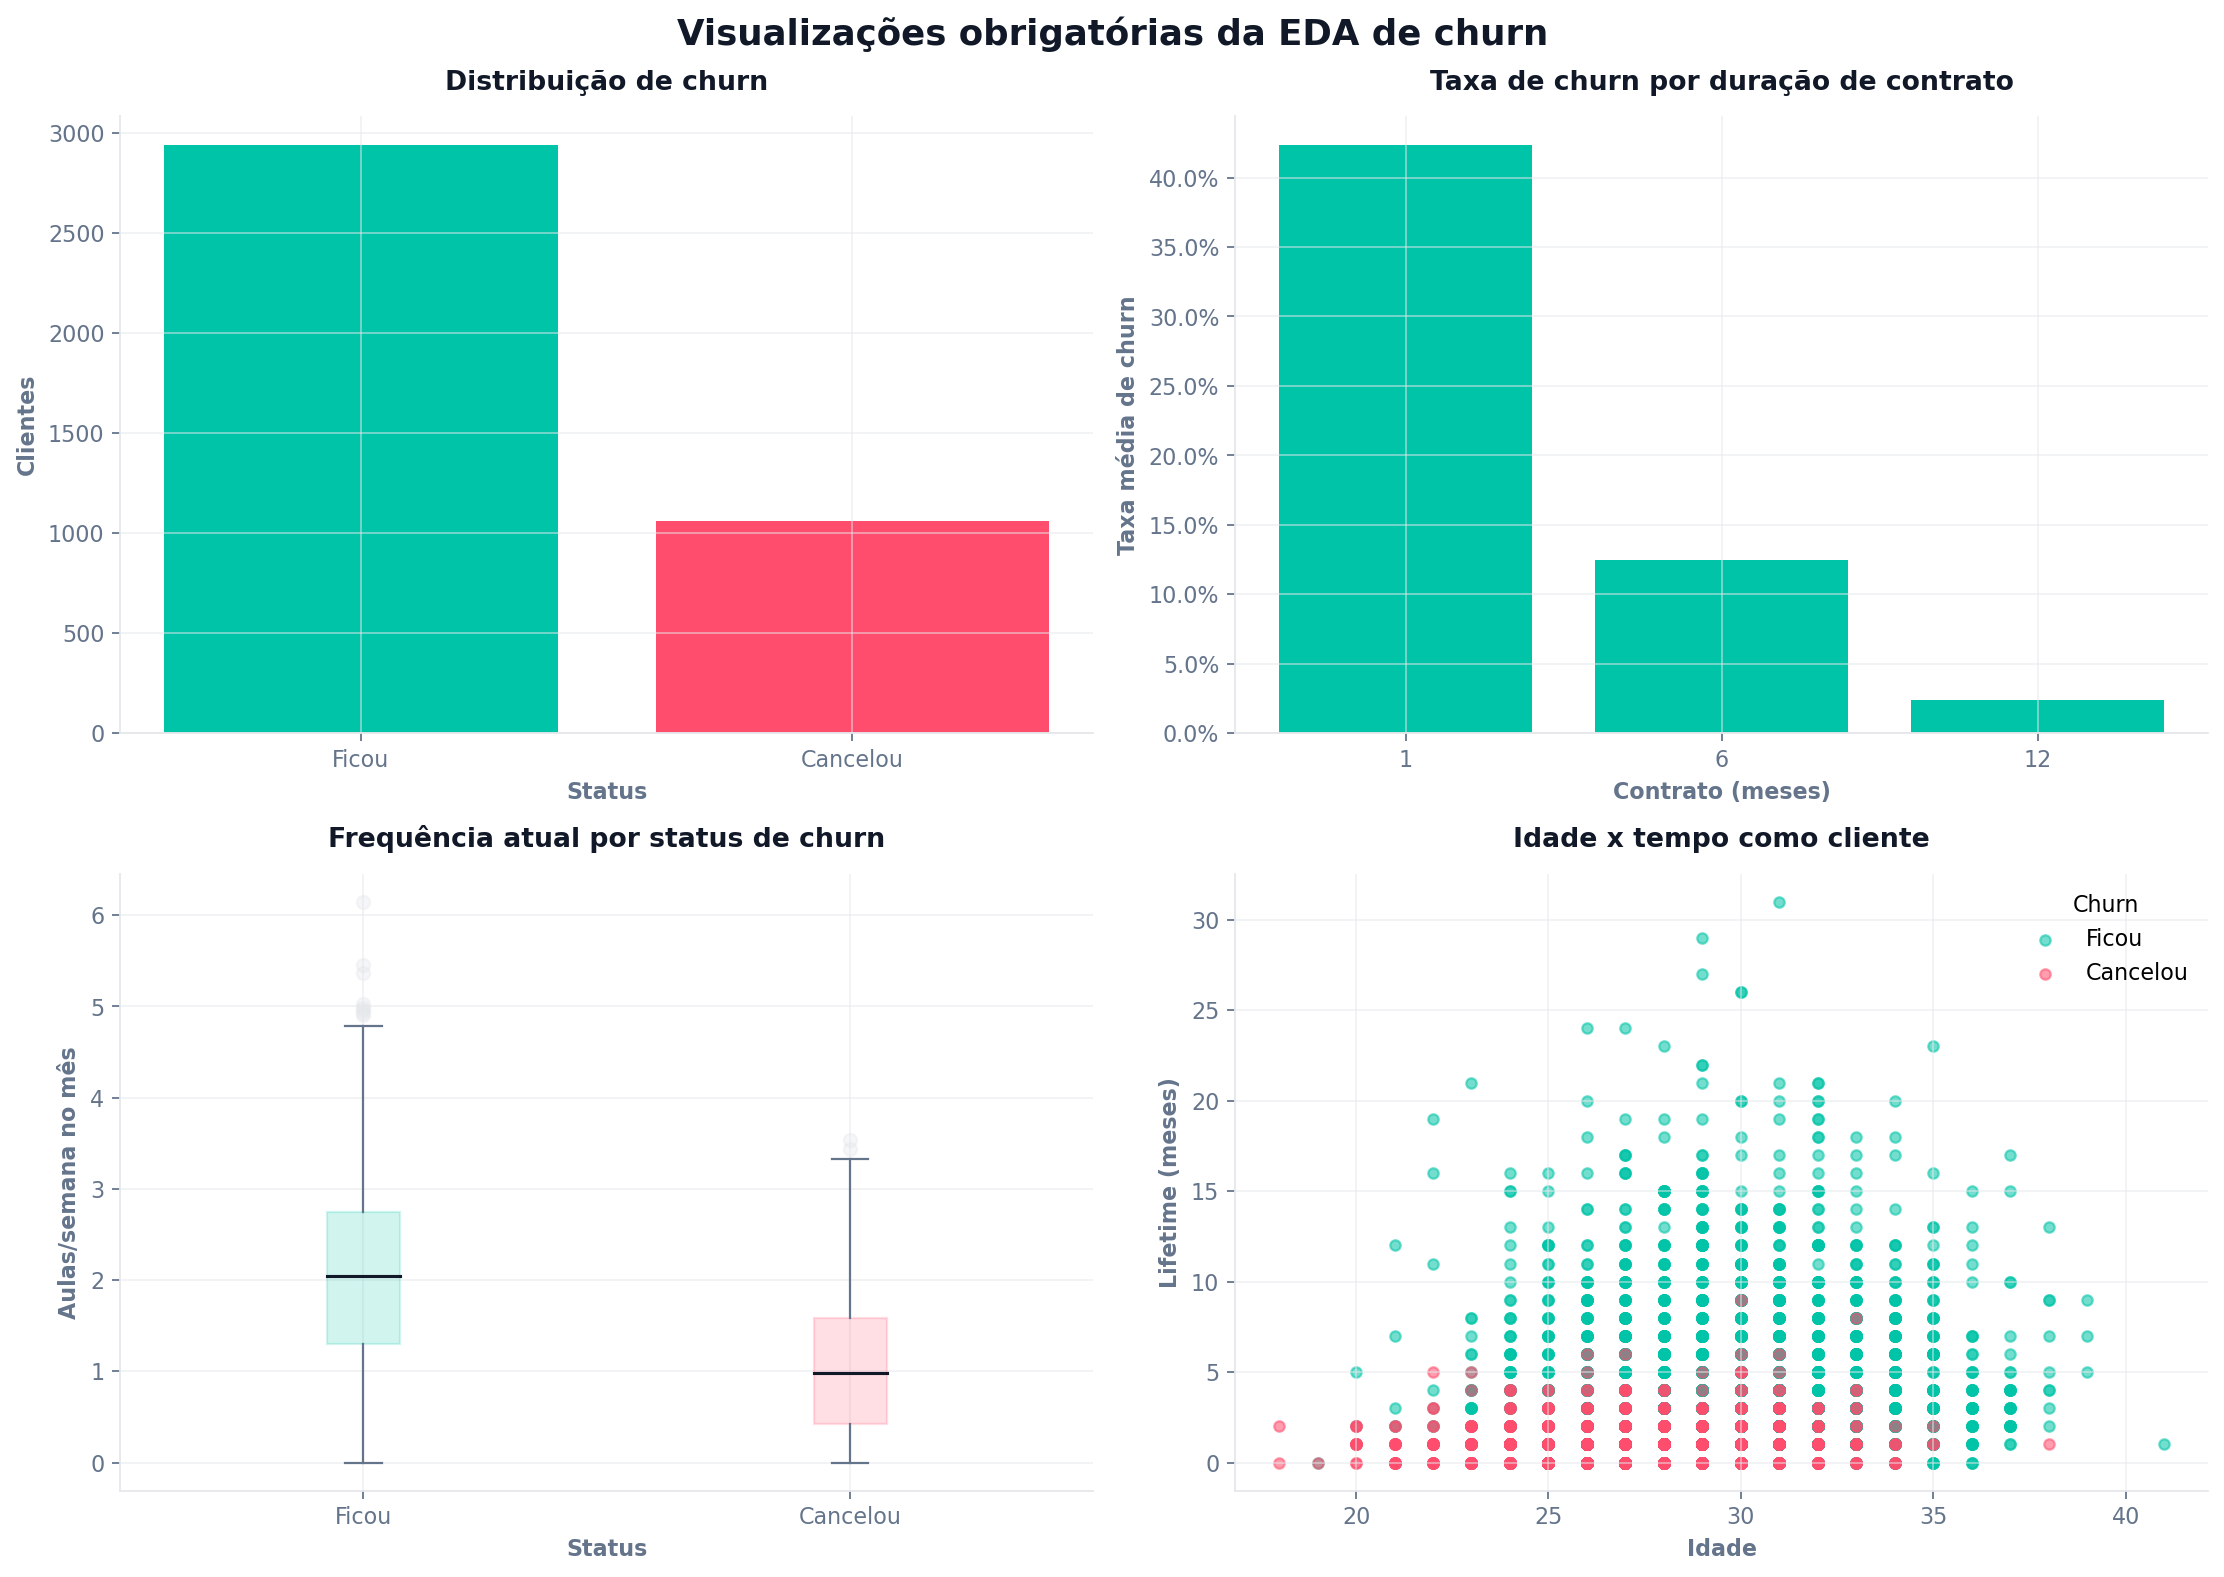

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Visualizações obrigatórias da EDA de churn", fontsize=16, fontweight="bold", color=COLOR_TEXT)

churn_counts = df_eda["Churn"].value_counts().sort_index()
axes[0, 0].bar(["Ficou", "Cancelou"], churn_counts.values, color=[COLOR_BRAND, COLOR_HIGH], edgecolor="none")
aplicar_estilo_axis(axes[0, 0], "Distribuição de churn", "Status", "Clientes")

contract_churn = df_eda.groupby("Contract_period")["Churn"].mean().sort_index()
axes[0, 1].bar(contract_churn.index.astype(str), contract_churn.values, color=COLOR_BRAND, edgecolor="none")
aplicar_estilo_axis(axes[0, 1], "Taxa de churn por duração de contrato", "Contrato (meses)", "Taxa média de churn")
axes[0, 1].yaxis.set_major_formatter(PercentFormatter(1.0))

box_data = [
    df_eda.loc[df_eda["Churn"] == 0, "Avg_class_frequency_current_month"],
    df_eda.loc[df_eda["Churn"] == 1, "Avg_class_frequency_current_month"],
]
criar_boxplot_status(axes[1, 0], box_data)
aplicar_estilo_axis(axes[1, 0], "Frequência atual por status de churn", "Status", "Aulas/semana no mês")

for churn_value, color, label in [(0, COLOR_BRAND, "Ficou"), (1, COLOR_HIGH, "Cancelou")]:
    subset = df_eda[df_eda["Churn"] == churn_value]
    axes[1, 1].scatter(subset["Age"], subset["Lifetime"], alpha=0.55, color=color, label=label, s=22)
aplicar_estilo_axis(axes[1, 1], "Idade x tempo como cliente", "Idade", "Lifetime (meses)", grid_axis="both")
axes[1, 1].legend(title="Churn", frameon=False)

plt.tight_layout()
plt.show()

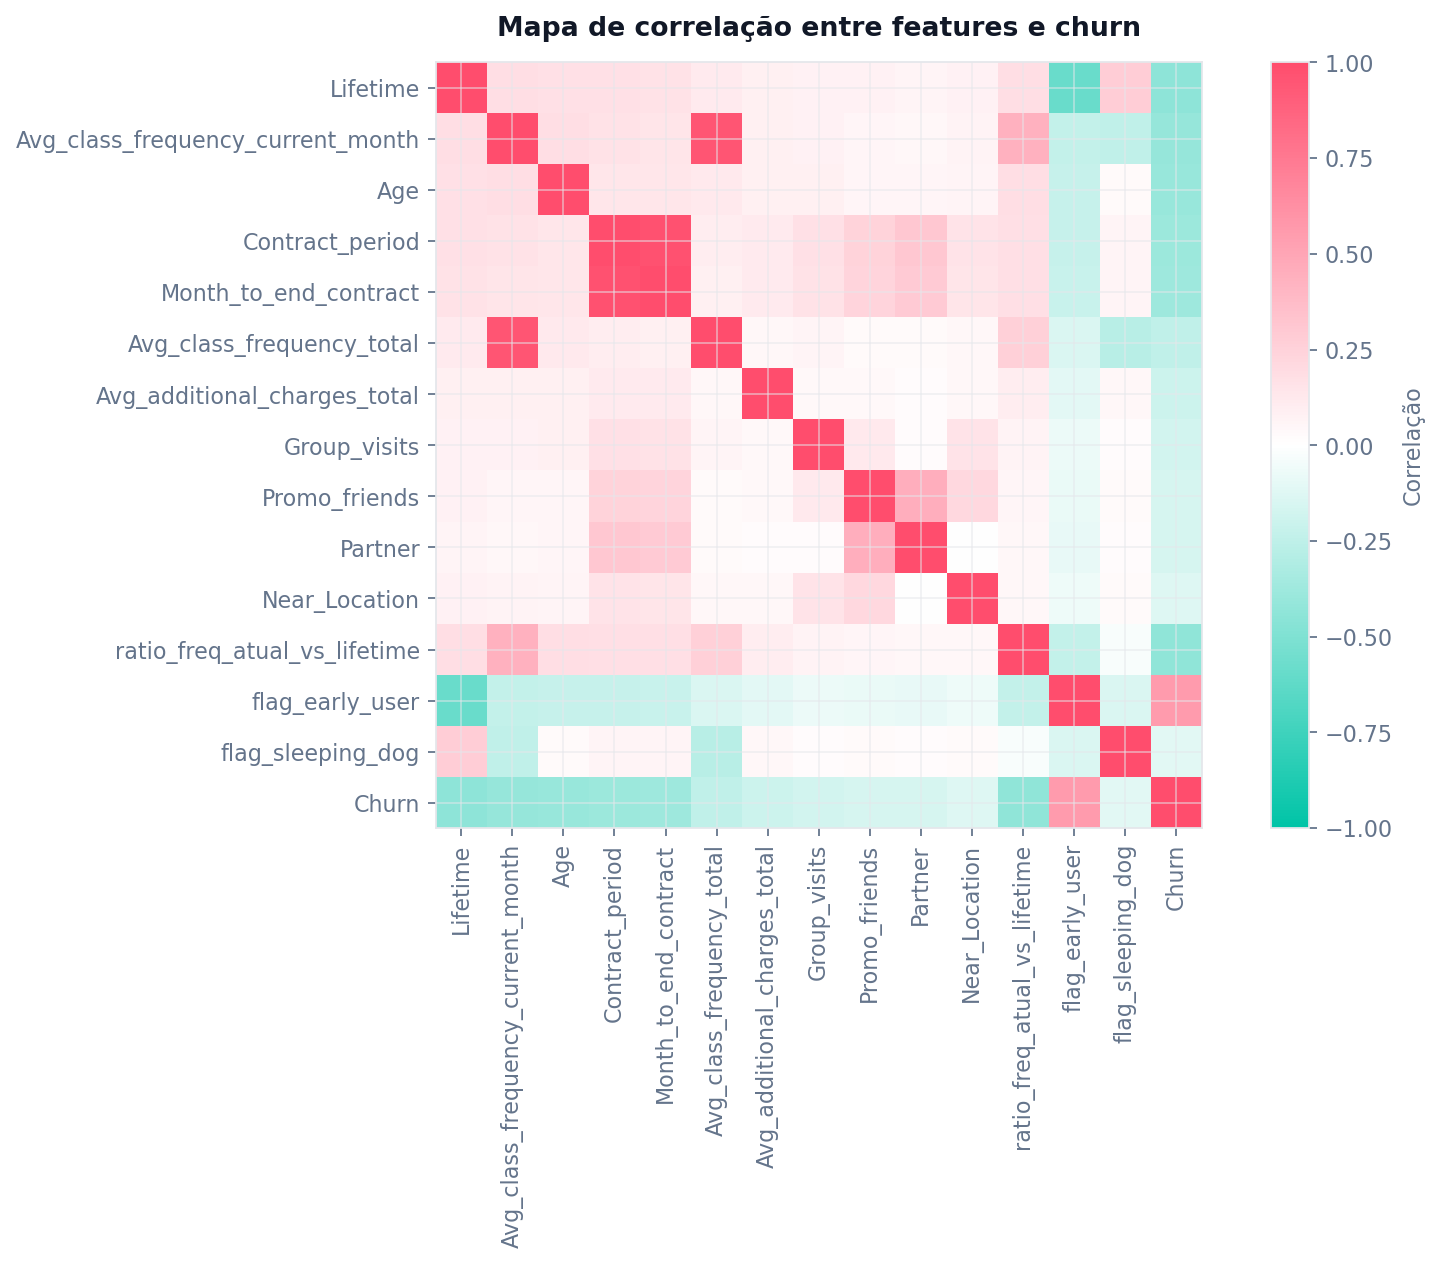

In [20]:
features_para_correlacao = FEATURES + [
    "ratio_freq_atual_vs_lifetime",
    "flag_early_user",
    "flag_sleeping_dog",
    "Churn",
]

corr_matrix = df_eda[features_para_correlacao].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(12, 8))
heatmap = ax.imshow(corr_matrix, cmap=CORRELATION_CMAP, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90, color=COLOR_MUTED)
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index, color=COLOR_MUTED)
ax.set_title("Mapa de correlação entre features e churn", fontweight="bold", color=COLOR_TEXT, pad=12)
for spine in ax.spines.values():
    spine.set_color(COLOR_BORDER)
fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04, label="Correlação")
plt.tight_layout()
plt.show()

correlacao_churn = (
    corr_matrix["Churn"]
    .drop("Churn")
    .sort_values(key=abs, ascending=False)
)

correlacao_churn.head(10).to_frame("correlacao_com_churn").round(3)

In [21]:
segmentos = pd.DataFrame({
    "segmento": [
        "Usuários novos",
        "Sleeping dogs",
        "Contrato curto",
        "Baixa frequência atual",
        "Sem visitas em grupo",
    ],
    "clientes": [
        int(df_eda["flag_early_user"].sum()),
        int(df_eda["flag_sleeping_dog"].sum()),
        int((df_eda["Contract_period"] <= 1).sum()),
        int((df_eda["Avg_class_frequency_current_month"] < 1).sum()),
        int((df_eda["Group_visits"] == 0).sum()),
    ],
    "churn_rate": [
        df_eda.loc[df_eda["flag_early_user"] == 1, "Churn"].mean(),
        df_eda.loc[df_eda["flag_sleeping_dog"] == 1, "Churn"].mean(),
        df_eda.loc[df_eda["Contract_period"] <= 1, "Churn"].mean(),
        df_eda.loc[df_eda["Avg_class_frequency_current_month"] < 1, "Churn"].mean(),
        df_eda.loc[df_eda["Group_visits"] == 0, "Churn"].mean(),
    ],
})
segmentos["churn_rate"] = segmentos["churn_rate"].fillna(0).round(3)
segmentos.sort_values("churn_rate", ascending=False)

## 13. Leitura executiva das features derivadas

As features derivadas ajudam a traduzir comportamento em ação:

- queda na frequência recente indica perda de hábito e deve acionar contato preventivo;
- clientes no início do relacionamento precisam de onboarding ativo;
- clientes antigos com baixa frequência são bons candidatos a campanhas de reativação;
- contratos curtos concentram maior vulnerabilidade e merecem incentivo para migração de plano;
- ausência de aulas em grupo sugere menor vínculo social com a academia.

## 14. Versão consolidada do Dashboard EDA

Esta seção replica a leitura visual da aba **Dashboard EDA** do site. O objetivo é manter notebook e interface com a mesma narrativa:

- percentuais de correlação são apresentados como **força da relação estatística**, não como taxa de churn;
- gráficos de frequência e sobrevivência trazem eixos mais explícitos;
- a curva de sobrevivência é agregada por `Lifetime`, não por perfil individual;
- segmentos diagnósticos aparecem como grupos acionáveis para retenção.

In [22]:
dashboard_df = df_eda.copy() if "df_eda" in globals() else df_clean.copy()

if "ratio_freq_atual_vs_lifetime" not in dashboard_df.columns:
    dashboard_df["ratio_freq_atual_vs_lifetime"] = (
        dashboard_df["Avg_class_frequency_current_month"]
        / dashboard_df["Avg_class_frequency_total"].replace(0, np.nan)
    ).fillna(0)

if "flag_early_user" not in dashboard_df.columns:
    dashboard_df["flag_early_user"] = (dashboard_df["Lifetime"] <= 1).astype(int)

if "flag_sleeping_dog" not in dashboard_df.columns:
    dashboard_df["flag_sleeping_dog"] = (
        (dashboard_df["Lifetime"] > 6)
        & (dashboard_df["Avg_class_frequency_current_month"] < 0.5)
    ).astype(int)

feature_labels_dashboard = {
    "Lifetime": "Tempo como cliente",
    "Avg_class_frequency_current_month": "Frequência atual",
    "Age": "Idade",
    "Contract_period": "Duração do contrato",
    "Month_to_end_contract": "Meses até vencer",
    "Avg_class_frequency_total": "Frequência histórica",
    "Avg_additional_charges_total": "Gastos extras",
    "Group_visits": "Aulas em grupo",
    "Promo_friends": "Indicação de amigos",
    "Partner": "Empresa parceira",
    "Near_Location": "Mora perto",
    "ratio_freq_atual_vs_lifetime": "Ratio freq. atual/histórica",
    "flag_early_user": "Usuário novo",
    "flag_sleeping_dog": "Sleeping dog",
}

features_dashboard = FEATURES + [
    "ratio_freq_atual_vs_lifetime",
    "flag_early_user",
    "flag_sleeping_dog",
]

corr_dashboard = (
    dashboard_df[features_dashboard + ["Churn"]]
    .corr(numeric_only=True)["Churn"]
    .drop("Churn")
    .sort_values(key=abs, ascending=False)
    .head(10)
)

correlacao_dashboard = pd.DataFrame({
    "feature": [feature_labels_dashboard.get(feature, feature) for feature in corr_dashboard.index],
    "forca_relacao_percentual": (corr_dashboard.abs() * 100).round(1),
    "direcao": [
        "associado a mais churn" if value >= 0 else "associado a menos churn"
        for value in corr_dashboard.values
    ],
    "observacao": "Percentual indica força da relação estatística, não taxa de cancelamento.",
})

correlacao_dashboard

In [23]:
survival_rows = []
survival_probability = 1.0
for lifetime in sorted(dashboard_df["Lifetime"].unique()):
    at_risk = dashboard_df[dashboard_df["Lifetime"] >= lifetime]
    events = dashboard_df[(dashboard_df["Lifetime"] == lifetime) & (dashboard_df["Churn"] == 1)]
    hazard = len(events) / len(at_risk) if len(at_risk) else 0
    survival_probability *= 1 - hazard
    survival_rows.append({
        "Lifetime": lifetime,
        "permanencia_estimada": survival_probability,
        "clientes_observados": len(at_risk),
        "churns_no_mes": len(events),
    })

survival_dashboard = pd.DataFrame(survival_rows)
survival_dashboard.head(10)

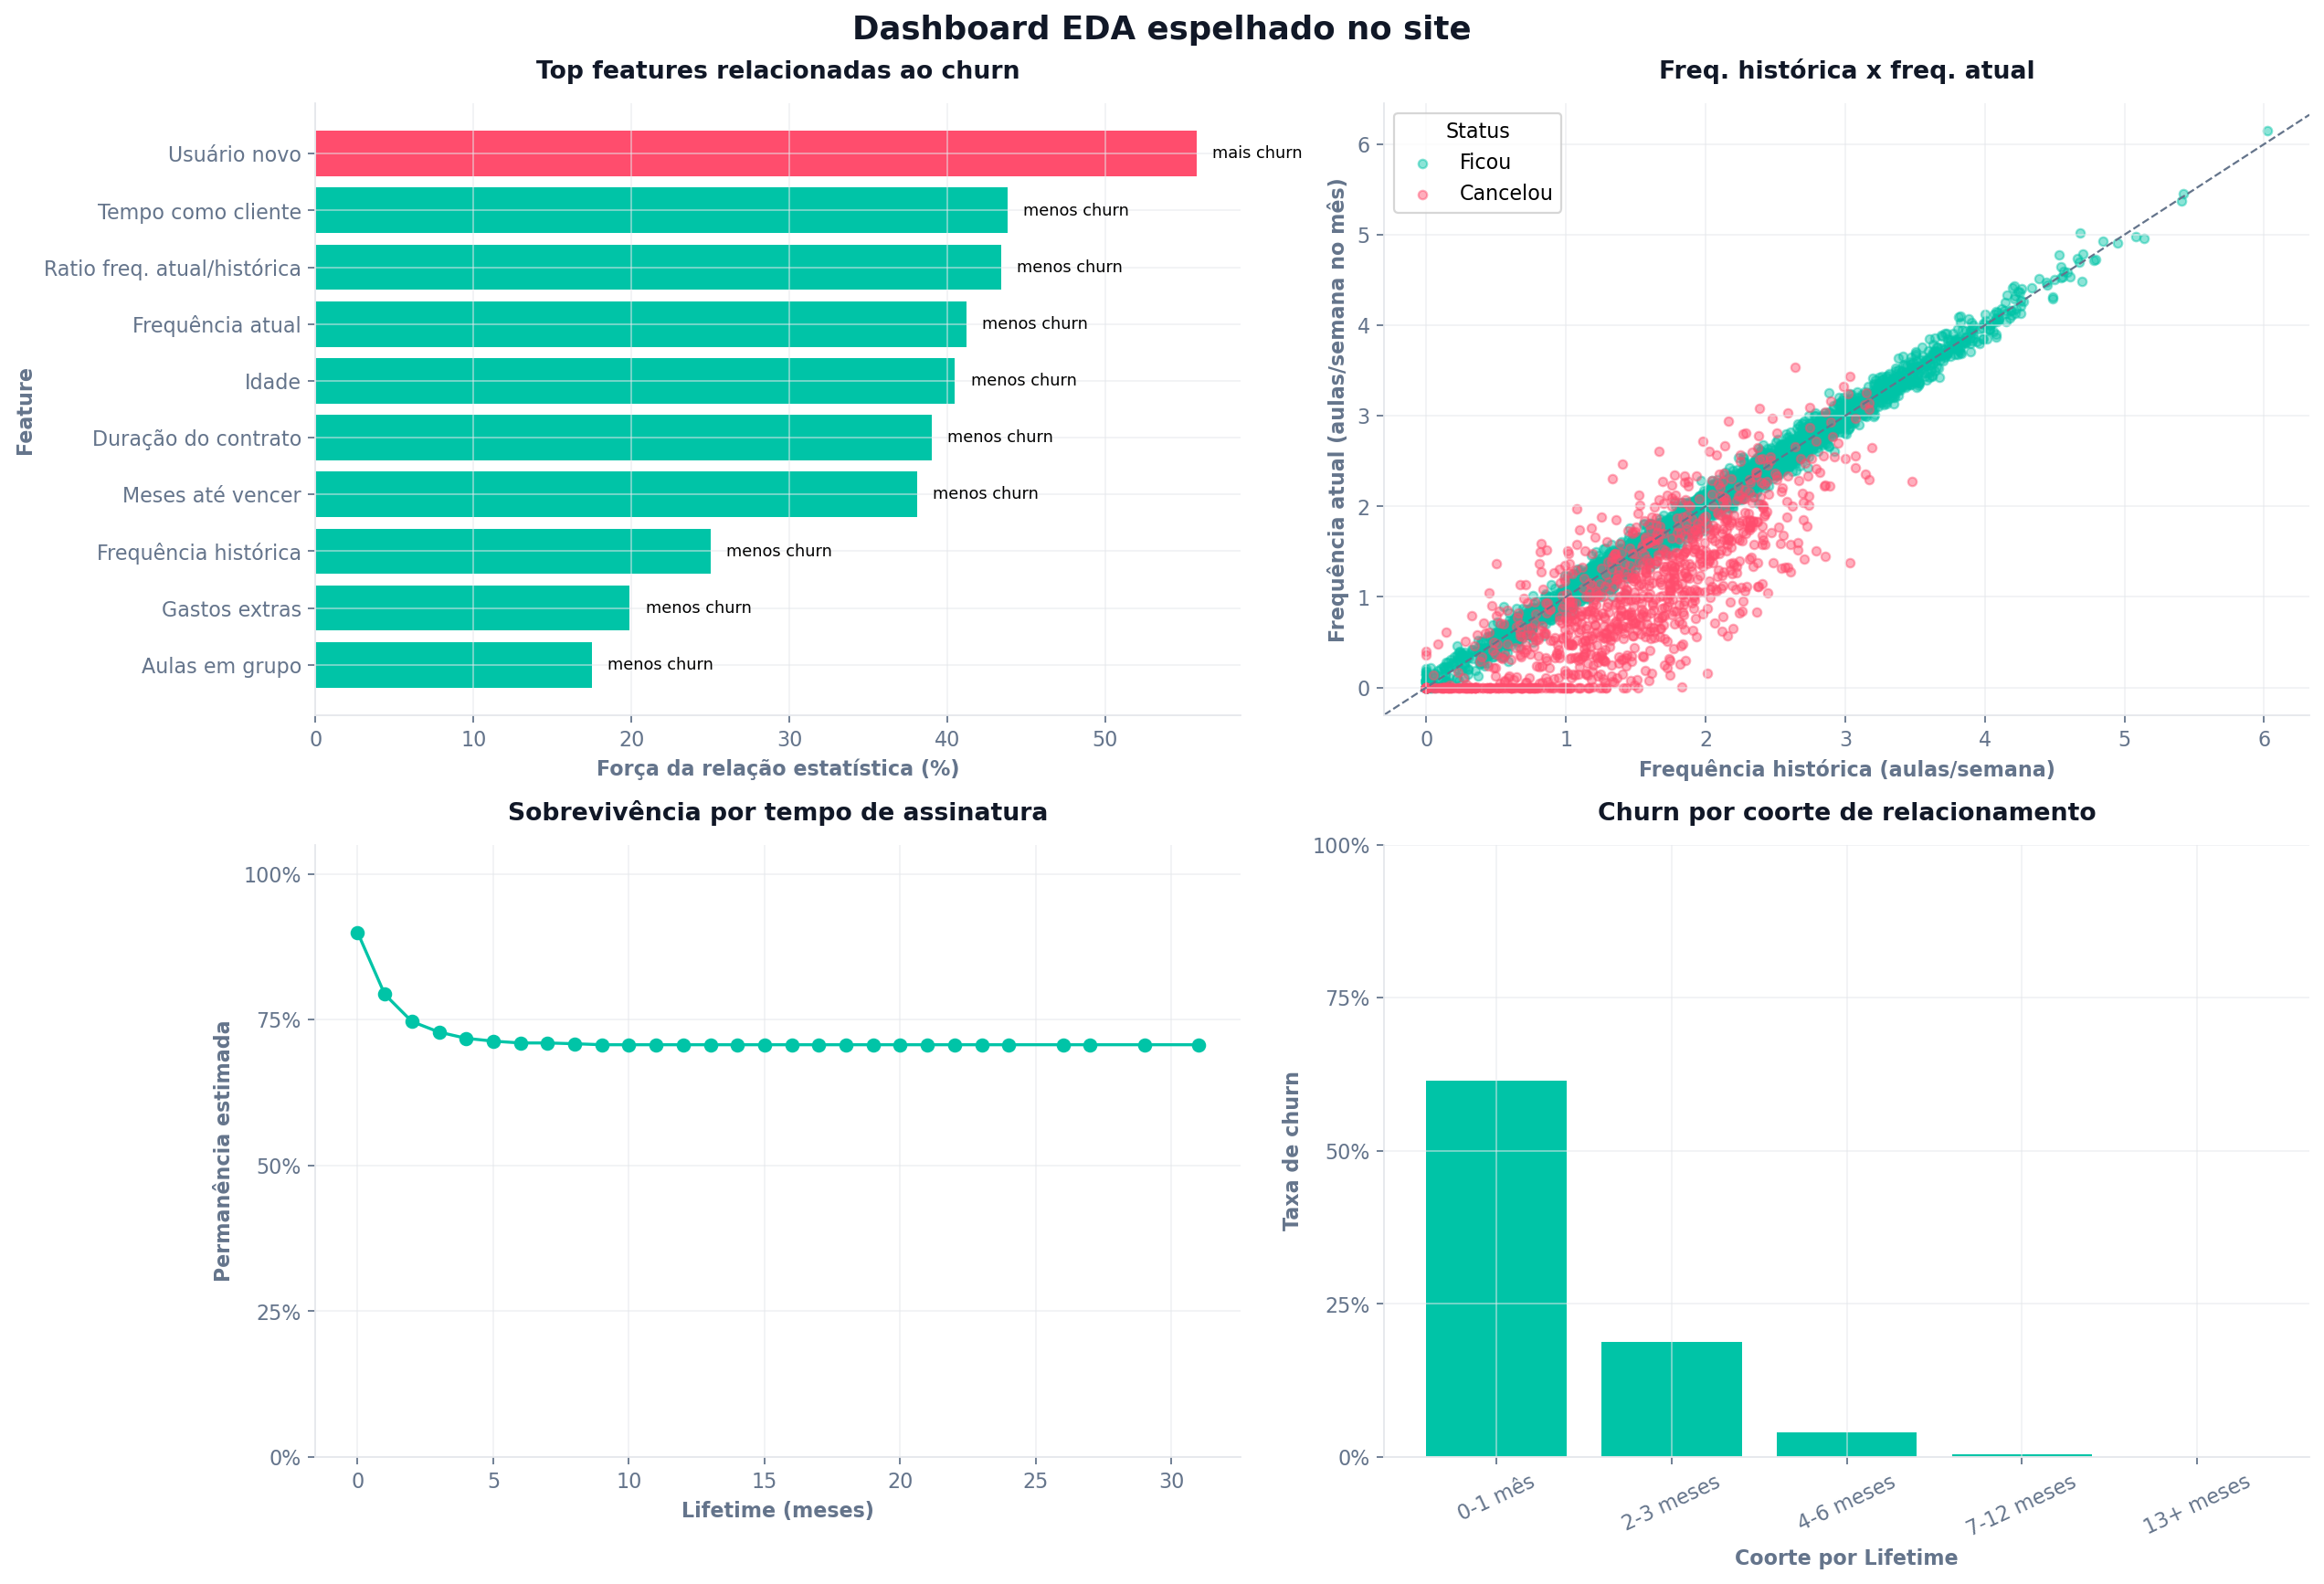

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Dashboard EDA espelhado no site", fontsize=16, fontweight="bold", color=COLOR_TEXT)

# Top features relacionadas ao churn, em linguagem do dashboard.
top_corr_plot = correlacao_dashboard.sort_values("forca_relacao_percentual", ascending=True)
colors = [
    COLOR_HIGH if direction == "associado a mais churn" else COLOR_BRAND
    for direction in top_corr_plot["direcao"]
]
axes[0, 0].barh(top_corr_plot["feature"], top_corr_plot["forca_relacao_percentual"], color=colors)
aplicar_estilo_axis(axes[0, 0], "Top features relacionadas ao churn", "Força da relação estatística (%)", "Feature", grid_axis="x")
for index, row in top_corr_plot.iterrows():
    axes[0, 0].text(
        row["forca_relacao_percentual"] + 1,
        top_corr_plot.index.get_loc(index),
        row["direcao"].replace("associado a ", ""),
        va="center",
        fontsize=8,
    )

# Scatter de frequência com eixo e legenda claros.
for churn_value, color, label in [(0, COLOR_BRAND, "Ficou"), (1, COLOR_HIGH, "Cancelou")]:
    subset = dashboard_df[dashboard_df["Churn"] == churn_value]
    axes[0, 1].scatter(
        subset["Avg_class_frequency_total"],
        subset["Avg_class_frequency_current_month"],
        alpha=0.45,
        s=18,
        color=color,
        label=label,
    )
axes[0, 1].axline((0, 0), slope=1, color=COLOR_MUTED, linestyle="--", linewidth=1)
aplicar_estilo_axis(axes[0, 1], "Freq. histórica x freq. atual", "Frequência histórica (aulas/semana)", "Frequência atual (aulas/semana no mês)", grid_axis="both")
axes[0, 1].legend(title="Status")


# Curva de sobrevivência com grade percentual.
axes[1, 0].plot(
    survival_dashboard["Lifetime"],
    survival_dashboard["permanencia_estimada"],
    marker="o",
    color=COLOR_BRAND,
)
aplicar_estilo_axis(axes[1, 0], "Sobrevivência por tempo de assinatura", "Lifetime (meses)", "Permanência estimada", grid_axis="both")
axes[1, 0].set_ylim(0, 1.05)
axes[1, 0].set_yticks([0, 0.25, 0.50, 0.75, 1.00])
axes[1, 0].yaxis.set_major_formatter(PercentFormatter(1.0))


# Churn por coorte de relacionamento.
cohort_bins = [-1, 1, 3, 6, 12, float("inf")]
cohort_labels = ["0-1 mês", "2-3 meses", "4-6 meses", "7-12 meses", "13+ meses"]
dashboard_df["cohort_lifetime"] = pd.cut(
    dashboard_df["Lifetime"],
    bins=cohort_bins,
    labels=cohort_labels,
    include_lowest=True,
)
cohort_dashboard = dashboard_df.groupby("cohort_lifetime", observed=False)["Churn"].agg(["mean", "count"])
axes[1, 1].bar(cohort_dashboard.index.astype(str), cohort_dashboard["mean"], color=COLOR_BRAND, edgecolor="none")
aplicar_estilo_axis(axes[1, 1], "Churn por coorte de relacionamento", "Coorte por Lifetime", "Taxa de churn")
axes[1, 1].set_yticks([0, 0.25, 0.50, 0.75, 1.00])
axes[1, 1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1, 1].tick_params(axis="x", rotation=25)


plt.tight_layout()
plt.show()

### Como ler os fatores de risco da inferência

No site, os fatores de risco não são uma decomposição matemática que soma a probabilidade final. Eles são uma leitura explicativa dos principais sinais usados pelo RandomForest.

- **Referência do treino**: valor típico do CSV enviado. Para campos numéricos usamos a mediana; para campos Sim/Não usamos a opção mais comum.
- **Destaque no ranking**: peso relativo daquele fator dentro dos sinais exibidos na inferência.
- **Importância global no modelo**: importância geral da variável no RandomForest, calculada a partir do treino.
- **Probabilidade de churn**: vem do conjunto das árvores do modelo, considerando todas as features, e não da soma desses três fatores.